<a href="https://colab.research.google.com/github/manojgupta450/MachineLearning/blob/main/EDA_Assg_NYC_Taxi_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import re

# Select the folder having data files
os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')

# Filter to ensure we only read the twelve monthly files (e.g., 2023-1.parquet through 2023-12.parquet)
all_files = os.listdir()
pattern = re.compile(r'^2023-(1[0-2]|[1-9])\.parquet$')
file_list = sorted([f for f in all_files if pattern.match(f)])

# Initialise an empty dataframe
df = pd.DataFrame()

# Iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # File path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        print(f"Processing and sampling from {file_name}...")

        # Reading the current file
        month_data = pd.read_parquet(file_path)

        # Ensure datetime column is parsed
        month_data['tpep_pickup_datetime'] = pd.to_datetime(month_data['tpep_pickup_datetime'])

        # Extract date and hour for sampling
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour

        # Group by date and hour, then sample 5% (frac=0.05) from each group
        sampled_month_data = month_data.groupby(['pickup_date', 'pickup_hour'], group_keys=False).apply(
            lambda x: x.sample(frac=0.05, random_state=42) if len(x) > 0 else x
        )

        # Concatenate the sampled data of the current month to the main dataframe
        df = pd.concat([df, sampled_month_data], ignore_index=True)
        print(f"Completed {file_name}. Cumulative shape: {df.shape}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Processing and sampling from 2023-1.parquet...
Completed 2023-1.parquet. Cumulative shape: (152087, 21)
Processing and sampling from 2023-10.parquet...
Completed 2023-10.parquet. Cumulative shape: (326342, 22)
Processing and sampling from 2023-11.parquet...
Completed 2023-11.parquet. Cumulative shape: (491475, 22)
Processing and sampling from 2023-12.parquet...
Completed 2023-12.parquet. Cumulative shape: (658184, 22)
Processing and sampling from 2023-2.parquet...
Completed 2023-2.parquet. Cumulative shape: (826880, 22)
Processing and sampling from 2023-3.parquet...
Completed 2023-3.parquet. Cumulative shape: (990666, 22)
Processing and sampling from 2023-4.parquet...
Completed 2023-4.parquet. Cumulative shape: (1130307, 22)
Processing and sampling from 2023-5.parquet...
Completed 2023-5.parquet. Cumulative shape: (1274765, 22)
Processing and sampling from 2023-6.parquet...
Completed 2023-6.parquet. Cumulative shape: (1437675, 22)
Processing and sampling from 2023-7.parquet...
Complete

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in parquet format for fast and efficient subsequent loading
saved_path = 'sampled_trip_records_2023.parquet'
df.to_parquet(saved_path)
print(f"Combined sampled dataframe successfully saved to {saved_path}")

Combined sampled dataframe successfully saved to sampled_trip_records_2023.parquet


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('sampled_trip_records_2023.parquet')
print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (1896400, 22)


In [ ]:
# Show the first few rows of the sampled dataset
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23,NaN
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN


In [ ]:
# Show the concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
print("Index successfully reset. Current columns:", df.columns.tolist())

Index successfully reset. Current columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour', 'Airport_fee']


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Combine the two airport fee columns
# Fill any NaN values in 'airport_fee' with values from 'Airport_fee'
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

# Drop the redundant 'Airport_fee' column
df.drop(columns=['Airport_fee'], inplace=True, errors='ignore')

# Confirm the remaining columns and non-null values in airport_fee
print("Columns after combining airport fee columns:", df.columns.tolist())
print(f"Missing values remaining in 'airport_fee': {df['airport_fee'].isna().sum()}")

Columns after combining airport fee columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour']
Missing values remaining in 'airport_fee': 64874


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# Check where values of fare_amount are negative
negative_fares = df[df['fare_amount'] < 0]
print(f"Number of records with negative fare amounts: {len(negative_fares)}")
negative_fares[['fare_amount', 'total_amount', 'RatecodeID', 'payment_type']].head()

Number of records with negative fare amounts: 0


,fare_amount,total_amount,RatecodeID,payment_type


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0]['RatecodeID'].value_counts()



,count
RatecodeID,


In [ ]:
# Find which columns have negative values
numeric_cols = df.select_dtypes(include=['number'])
negative_columns = numeric_cols.loc[:, (numeric_cols < 0).any()].columns
print("Columns with negative values:", list(negative_columns))

Columns with negative values: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [ ]:
# fix these negative values
for col in negative_columns:
    df.loc[df[col] < 0, col] = 0

print("Fixed. Recheck remaining negatives.")
for col in negative_columns:
    print(f"  {col}: {(df[col] < 0).sum()} values remaining")

Fixed. Recheck remaining negatives.
  extra: 0 values remaining
  mta_tax: 0 values remaining
  improvement_surcharge: 0 values remaining
  total_amount: 0 values remaining
  congestion_surcharge: 0 values remaining
  airport_fee: 0 values remaining


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportions = df.isna().mean() * 100
print("Proportion of missing values in each column (%):")
print(missing_proportions[missing_proportions > 0].sort_values(ascending=False))

Proportion of missing values in each column (%):
passenger_count         3.420903
RatecodeID              3.420903
store_and_fwd_flag      3.420903
congestion_surcharge    3.420903
airport_fee             3.420903
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display a sample of rows with null values in passenger_count
print("Sample of rows with null passenger_count:")
display(df[df['passenger_count'].isna()].head())

# Calculate the mode of passenger_count
passenger_mode = df['passenger_count'].mode()[0]
print(f"\nMost frequent passenger count (mode): {passenger_mode}")

# Impute NaN values in 'passenger_count' with the mode
df['passenger_count'] = df['passenger_count'].fillna(passenger_mode)

# Check if there are passenger counts equal to 0
zero_passenger_count = (df['passenger_count'] == 0).sum()
print(f"Number of records where passenger_count is 0: {zero_passenger_count}")

# Replace 0 passenger counts with the mode as well
if zero_passenger_count > 0:
    df.loc[df['passenger_count'] == 0, 'passenger_count'] = passenger_mode
    print("Successfully replaced 0 passenger counts with the mode.")

# Confirm no missing or zero values remain
print(f"Remaining missing values in passenger_count: {df['passenger_count'].isna().sum()}")
print(f"Remaining 0 values in passenger_count: {(df['passenger_count'] == 0).sum()}")

Sample of rows with null passenger_count:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour
5,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN,2023-01-01,0
16,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,...,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN,2023-01-01,0
43,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,...,0.0,0.5,0.00,0.00,1.0,29.38,NaN,NaN,2023-01-01,0
44,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,...,0.0,0.5,2.20,0.00,1.0,46.20,NaN,NaN,2023-01-01,0
47,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,...,0.0,0.5,3.37,0.00,1.0,25.85,NaN,NaN,2023-01-01,0



Most frequent passenger count (mode): 1.0
Number of records where passenger_count is 0: 29681
Successfully replaced 0 passenger counts with the mode.
Remaining missing values in passenger_count: 0
Remaining 0 values in passenger_count: 0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Calculate the mode of RatecodeID
ratecode_mode = df['RatecodeID'].mode()[0]
print(f"Most frequent RatecodeID (mode): {ratecode_mode}")

# Impute NaN values in 'RatecodeID' with the mode
df['RatecodeID'] = df['RatecodeID'].fillna(ratecode_mode)

# Confirm no missing values remain in RatecodeID
print(f"Remaining missing values in RatecodeID: {df['RatecodeID'].isna().sum()}")

Most frequent RatecodeID (mode): 1.0
Remaining missing values in RatecodeID: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# Check the value distribution of congestion_surcharge
print("Value distribution of congestion_surcharge:")
print(df['congestion_surcharge'].value_counts(dropna=False))

# Calculate the mode of congestion_surcharge
congestion_mode = df['congestion_surcharge'].mode()[0]
print(f"\nMost frequent congestion_surcharge (mode): {congestion_mode}")

# Impute NaN values in 'congestion_surcharge' with the mode
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(congestion_mode)

# Confirm no missing values remain in congestion_surcharge
print(f"Remaining missing values in congestion_surcharge: {df['congestion_surcharge'].isna().sum()}")

Value distribution of congestion_surcharge:
congestion_surcharge
2.5    1690572
0.0     140953
NaN      64874
0.5          1
Name: count, dtype: int64

Most frequent congestion_surcharge (mode): 2.5
Remaining missing values in congestion_surcharge: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Check missing values in 'store_and_fwd_flag' and 'airport_fee'
print("Missing values before imputation:")
print(df[['store_and_fwd_flag', 'airport_fee']].isna().sum())

# Calculate and fill with mode/default
store_mode = df['store_and_fwd_flag'].mode()[0]
print(f"\nMost frequent store_and_fwd_flag: {store_mode}")
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(store_mode)

# For airport fee, missing values are typically trips that did not start at an airport. We'll impute with 0.0
df['airport_fee'] = df['airport_fee'].fillna(0.0)

# Confirm that no missing values remain in the entire DataFrame
print("\nRemaining missing values in the dataset:")
print(df.isna().sum())

Missing values before imputation:
store_and_fwd_flag    64874
airport_fee           64874
dtype: int64

Most frequent store_and_fwd_flag: N

Remaining missing values in the dataset:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
pickup_date              0
pickup_hour              0
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

Descriptive statistics for numerical columns:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,1.896400e+06,1896400,1896400,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.733026e+00,2023-07-02 19:59:52.930795,2023-07-02 20:17:18.919563,1.372236e+00,3.858293e+00,1.612981e+00,1.652814e+02,1.640515e+02,1.163817e+00,1.991935e+01,1.588020e+00,4.952989e-01,3.547011e+00,5.965338e-01,9.990118e-01,2.898201e+01,2.314182e+00,1.380220e-01,1.426504e+01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:10:08.750000,2023-04-02 16:27:43.500000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00,1.100000e+01
50%,2.000000e+00,2023-06-27 15:44:22.500000,2023-06-27 16:01:15,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00,1.500000e+01
75%,2.000000e+00,2023-10-06 19:37:45,2023-10-06 19:53:39,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00,1.900000e+01
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00,2.300000e+01
std,4.476401e-01,NaN,NaN,8.644038e-01,1.294085e+02,7.267261e+00,6.400038e+01,6.980207e+01,5.081384e-01,1.055371e+02,1.829197e+00,4.855675e-02,4.054882e+00,2.187878e+00,2.907216e-02,1.064162e+02,6.557557e-01,4.575627e-01,5.807381e+00



Checking specific extremes:
Maximum trip distance: 126360.46 miles
Maximum fare amount: $143163.45
Minimum fare amount: $0.0
Unique payment types: [1, 2, 0, 4, 3]
Unique passenger counts: [1.0, 2.0, 3.0, 4.0, 6.0, 5.0, 8.0, 7.0, 9.0]


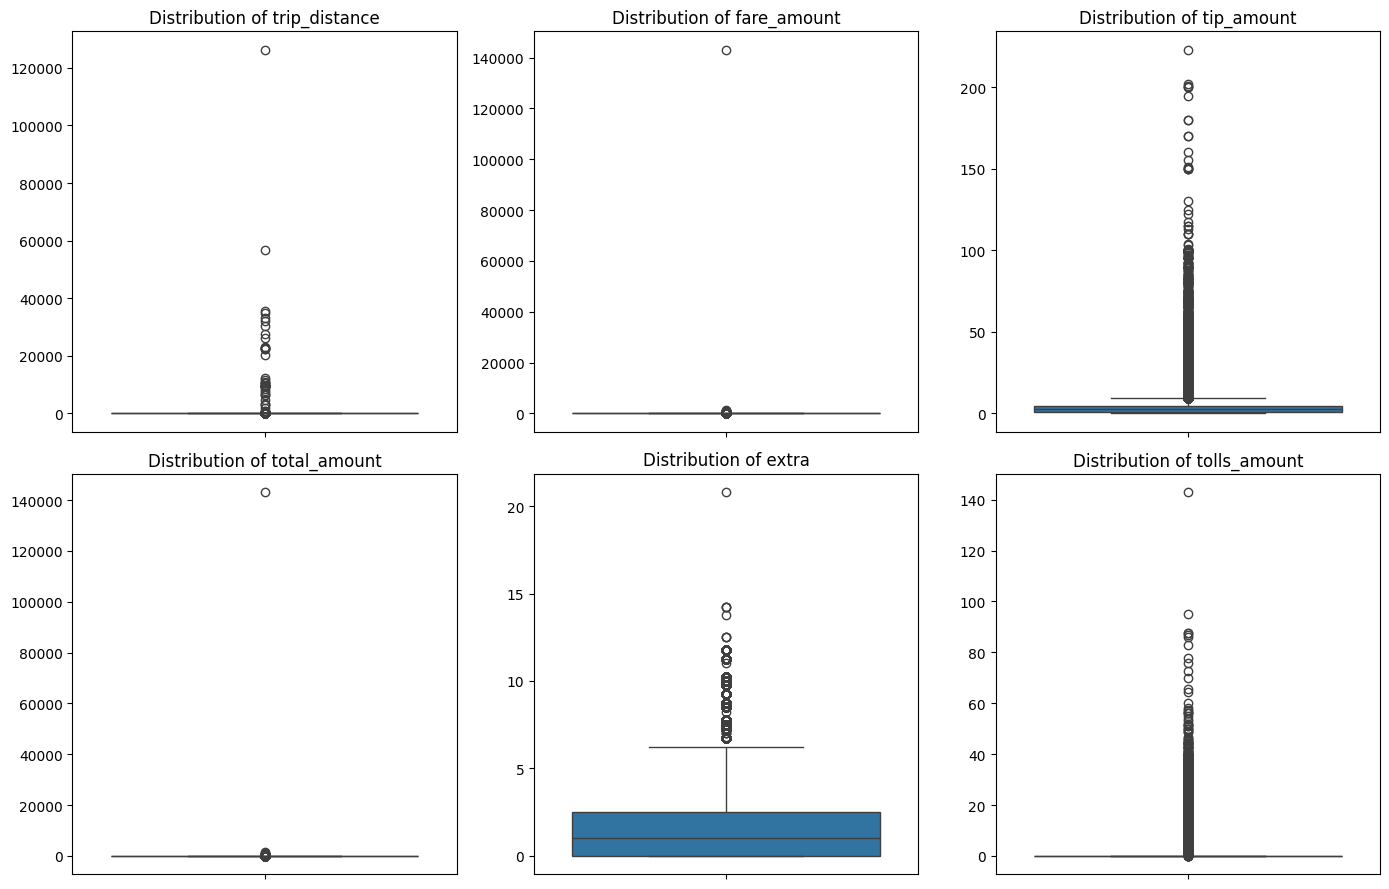

In [ ]:
# Describe the data and check if there are any potential outliers present
print("Descriptive statistics for numerical columns:")
display(df.describe())

# Check for potential out of place values in various columns
print("\nChecking specific extremes:")
print(f"Maximum trip distance: {df['trip_distance'].max()} miles")
print(f"Maximum fare amount: ${df['fare_amount'].max()}")
print(f"Minimum fare amount: ${df['fare_amount'].min()}")
print(f"Unique payment types: {df['payment_type'].unique().tolist()}")
print(f"Unique passenger counts: {df['passenger_count'].unique().tolist()}")

columns_of_interest = [
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'total_amount',
    'extra',
    'tolls_amount'
]
plt.figure(figsize=(14, 9))

for idx, column in enumerate(columns_of_interest, start=1):
    plt.subplot(2, 3, idx)
    sns.boxplot(data=df, y=column)
    plt.title(f'Distribution of {column}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# Remove passenger_count > 6 and passenger_count < 1
initial_count = len(df)
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
print(f"Removed {initial_count - len(df)} records with invalid passenger counts.")
print(f"Remaining records: {len(df)}")

Removed 21 records with invalid passenger counts.
Remaining records: 1896379


In [ ]:
# Continue with outlier handling
initial_records = len(df)

# 1. Remove extreme distance outliers (> 250 miles)
df = df[df['trip_distance'] <= 250]

# 2. Remove anomalous trips with near-zero distance (< 0.1) but extremely high fare (> $300)
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# 3. Remove trips where distance and fare are 0 but PULocationID != DOLocationID
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# 4. Filter out invalid payment_type 0
df = df[df['payment_type'] != 0]

# 5. negative trip durations (if duration feature already exists)
if 'trip_duration_min' in df.columns:
    df = df[df['trip_duration_min'] >= 0]

# 6. added filters for clearly invalid fare values

df = df[df['fare_amount'] > 0]       # zero fare (non-dispute) doesn't make sense
df = df[df['fare_amount'] < 1000]    # anything over $1000 is almost certainly an error
df = df[df['total_amount'] < 1000]   # same logic for total amount

# 7. reset index after all the filtering — keeps things tidy
#df = df.reset_index(drop=True)       # #FIXED — was missing after row drops

print(f"Outlier handling complete.")
print(f"Removed {initial_records - len(df)} outlier records.")
print(f"New dataset shape: {df.shape}")

Outlier handling complete.
Removed 65565 outlier records.
New dataset shape: (1830814, 21)


In [ ]:
# Added columns as required later

# Calculate and standardise trip duration in minutes
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Add trip duration in minutes
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Ensure no extreme duration outliers exist (e.g. negative durations or trips lasting more than 24 hours/1440 minutes)
df = df[df['trip_duration_min'] > 0]
df = df[df['trip_duration_min'] <= 1440]

# Add time features for analysis
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6])

# Map payment_type to labels
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided Trip'}
df['payment_label'] = df['payment_type'].map(payment_map)

# Fare per mile (for pricing analysis)
df['fare_per_mile'] = np.where(df['trip_distance'] > 0,
                                df['fare_amount'] / df['trip_distance'], np.nan)

# Average trip speed in mph
df['speed_mph'] = np.where(df['trip_duration_min'] > 0,
                            df['trip_distance'] / (df['trip_duration_min'] / 60), np.nan)
# Reset index
df = df.reset_index(drop=True)

print("Standardisation complete. Final columns:", df.columns.tolist())
print(f"Final clean dataframe shape: {df.shape}")
display(df[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration_min', 'trip_distance']].head())


Standardisation complete. Final columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour', 'trip_duration_min', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_weekend', 'payment_label', 'fare_per_mile', 'speed_mph']
Final clean dataframe shape: (1830120, 29)


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min,trip_distance
0,2022-12-31 23:51:30,2022-12-31 23:56:06,4.600000,0.86
1,2023-01-01 00:07:18,2023-01-01 00:23:15,15.950000,7.74
2,2023-01-01 00:16:41,2023-01-01 00:21:46,5.083333,1.24
3,2023-01-01 00:14:03,2023-01-01 00:24:36,10.550000,1.44
4,2023-01-01 00:24:30,2023-01-01 00:29:55,5.416667,0.54


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_date',
 'pickup_hour',
 'trip_duration_min',
 'pickup_day',
 'pickup_month',
 'pickup_dayofweek',
 'is_weekend',
 'payment_label',
 'fare_per_mile',
 'speed_mph']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

#### **3.1** General EDA: Finding Patterns and Trends

**3.1.1** Categorise the variables into Numerical or Categorical.

* `VendorID`: **Categorical** (Nominal identifier for providers: 1 or 2)
* `tpep_pickup_datetime`: **Temporal/Datetime** (Continuous/interval-based)
* `tpep_dropoff_datetime`: **Temporal/Datetime** (Continuous/interval-based)
* `passenger_count`: **Categorical** (Discrete count - though numerically structured, it behaves like an ordinal group with classes 1-6)
* `trip_distance`: **Numerical** (Continuous interval/ratio ratio metric)
* `RatecodeID`: **Categorical** (Nominal codes representing standard rate, JFK, Newark, etc.)
* `PULocationID`: **Categorical** (Nominal location/zone zones 1-263)
* `DOLocationID`: **Categorical** (Nominal location/zone zones 1-263)
* `payment_type`: **Categorical** (Nominal codes representing Credit Card, Cash, etc.)
* `pickup_hour`: **Categorical / Numerical Discrete** (Typically treated as categorical cyclic or discrete intervals)
* `trip_duration_min`: **Numerical** (Continuous interval ratio metric)

---

#### **Monetary Parameters Category**

The following parameters: `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, `congestion_surcharge`, and `airport_fee` are all **Numerical** (Continuous ratio scale representation of money).

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

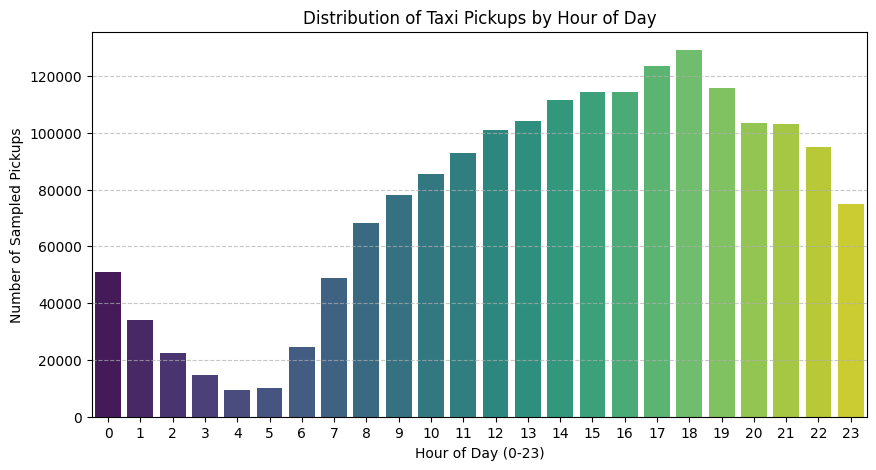

Peak hour: 18:00 with 129,115 trips
Least busy hour: 4:00 with 9,422 trips


In [ ]:
# Group by pickup_hour and calculate the total number of pickups
hourly_counts = df['pickup_hour'].value_counts().sort_index()

hourly_trips = (df.groupby('pickup_hour').size().reset_index(name='trip_count'))

# find peak and minimum hours
peak_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmax()]
min_hour = hourly_trips.loc[hourly_trips['trip_count'].idxmin()]

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='viridis')
plt.title('Distribution of Taxi Pickups by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Sampled Pickups')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# print both peak and minimum
print(
    f"Peak hour: {int(peak_hour['pickup_hour'])}:00 "
    f"with {peak_hour['trip_count']:,} trips"
)

print(
    f"Least busy hour: {int(min_hour['pickup_hour'])}:00 "
    f"with {min_hour['trip_count']:,} trips"
)

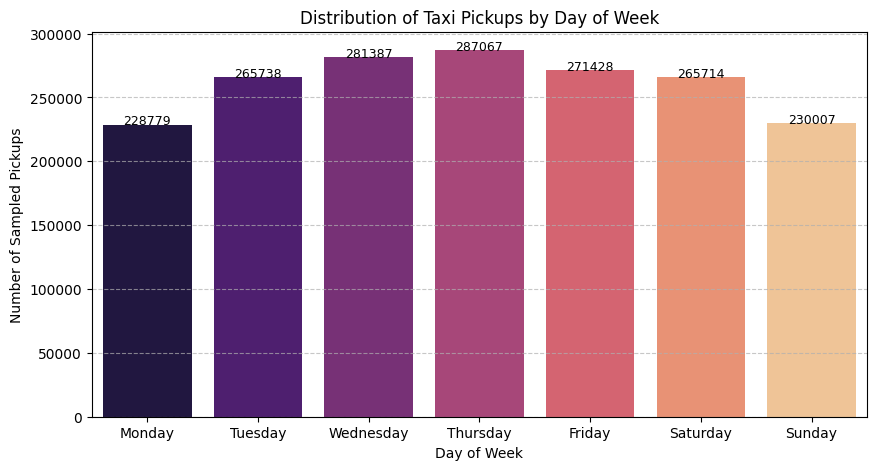

Most busy day: Thursday
Least busy day: Monday


In [ ]:
# Define the correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# count trips per day
daily_trips = df.groupby('pickup_day')['tpep_pickup_datetime'].count()
daily_trips = daily_trips.reindex(day_order)

# convert to dataframe (just easier to plot)
daily_df = daily_trips.reset_index()
daily_df.columns = ['day', 'count']

# find max and min (brownie points)
max_day = daily_df.loc[daily_df['count'].idxmax(), 'day']
min_day = daily_df.loc[daily_df['count'].idxmin(), 'day']

# Calculate day counts and order them
daily_counts = df['pickup_day'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_counts.index, y=daily_counts.values, palette='magma')
plt.title('Distribution of Taxi Pickups by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Sampled Pickups')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# add numbers on top (not perfectly aligned though)
for i in range(len(daily_df)):
    plt.text(i, daily_df['count'].iloc[i], str(daily_df['count'].iloc[i]), ha='center', fontsize=9)
plt.show()

print("Most busy day:", max_day)
print("Least busy day:", min_day)

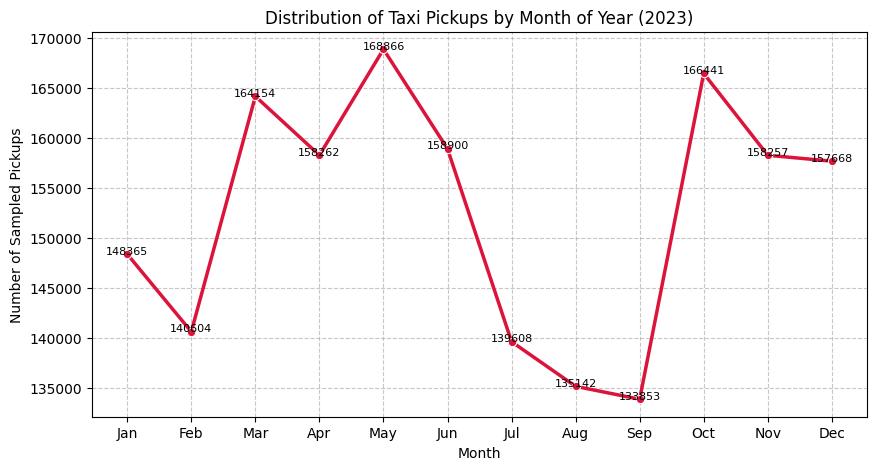

Most busy month: May
Least busy month: Sep


In [ ]:
# Group by pickup_month and calculate counts
monthly_counts = df['pickup_month'].value_counts().sort_index()

# count trips per month
monthly_trips = df.groupby('pickup_month')['tpep_pickup_datetime'].count()


# Map month numbers to short names for plotting
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_labels = [month_names[m] for m in monthly_counts.index]

monthly_trips = monthly_trips.reindex(month_names)
# make it a dataframe to make it easy dealing
monthly_df = monthly_trips.reset_index()
monthly_df.columns = ['month', 'count']

# find max and min (just for some drama)
max_month = monthly_df.loc[monthly_df['count'].idxmax(), 'month']
min_month = monthly_df.loc[monthly_df['count'].idxmin(), 'month']

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_labels, y=monthly_counts.values, marker='o', color='crimson', linewidth=2.5)
plt.title('Distribution of Taxi Pickups by Month of Year (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Sampled Pickups')
plt.grid(True, linestyle='--', alpha=0.7)
# numbers on top
for i in range(len(monthly_df)):
    plt.text(i, monthly_df['count'].iloc[i], str(monthly_df['count'].iloc[i]), ha='center', fontsize=8)
plt.show()

print("Most busy month:", month_names[max_month])
print("Least busy month:", month_names[min_month])

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyze zero and negative values in financial parameters
for col in ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']:
    zeros = (df[col] == 0).sum()
    negatives = (df[col] < 0).sum()
    print(f"{col} - Zeros: {zeros}, Negatives: {negatives}")

fare_amount - Zeros: 0, Negatives: 0
tip_amount - Zeros: 409071, Negatives: 0
total_amount - Zeros: 0, Negatives: 0
trip_distance - Zeros: 22075, Negatives: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a dataframe with logical non-zero entries for analysis
# We filter out trips where trip_distance is 0 AND PULocationID is different from DOLocationID
initial_len = len(df)
df = df[~((df['trip_distance'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# Also ensure fare_amount and total_amount are strictly positive for normal operational analysis
df = df[df['fare_amount'] > 0]
df = df[df['total_amount'] > 0]

# Reset index
df = df.reset_index(drop=True)

print(f"Filtering complete. Removed {initial_len - len(df)} records.")
print(f"New dataset shape: {df.shape}")

Filtering complete. Removed 7129 records.
New dataset shape: (1822991, 29)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

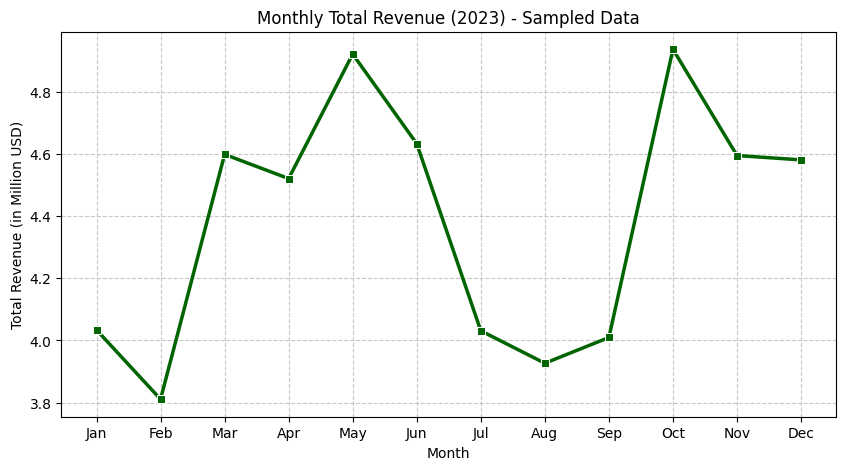

Jan: $4,033,836.05
Feb: $3,810,796.20
Mar: $4,598,745.96
Apr: $4,520,912.32
May: $4,921,583.20
Jun: $4,633,164.03
Jul: $4,031,030.37
Aug: $3,926,619.62
Sep: $4,009,508.80
Oct: $4,937,209.34
Nov: $4,595,082.16
Dec: $4,581,008.68

Total annual revenue (sampled data): $52,599,496.73


In [ ]:
# Group data by month and analyse monthly revenue
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

# Map month numbers to labels
month_labels = [month_names[m] for m in monthly_revenue.index]

# Plot monthly revenue trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=month_labels, y=monthly_revenue.values / 1e6, marker='s', color='darkgreen', linewidth=2.5)
plt.title('Monthly Total Revenue (2023) - Sampled Data')
plt.xlabel('Month')
plt.ylabel('Total Revenue (in Million USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Print summary of monthly revenue
for m, rev in zip(month_labels, monthly_revenue.values):
    print(f"{m}: ${rev:,.2f}")
print(f"\nTotal annual revenue (sampled data): ${monthly_revenue.sum():,.2f}")

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

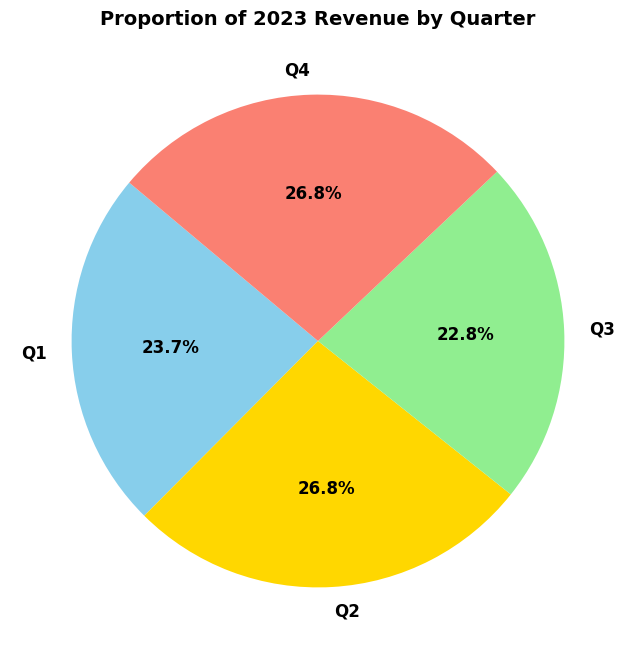

Q1: $12,443,378.21 (23.66%)
Q2: $14,075,659.55 (26.76%)
Q3: $11,967,158.79 (22.75%)
Q4: $14,113,300.18 (26.83%)


In [ ]:
# Map month to quarter
def get_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

df['quarter'] = df['pickup_month'].apply(get_quarter)

# Group and calculate total revenue and proportions
quarterly_revenue = df.groupby('quarter')['total_amount'].sum()
quarterly_proportions = (quarterly_revenue / quarterly_revenue.sum()) * 100

# Plot pie chart of quarterly revenue proportion
plt.figure(figsize=(8, 8))
plt.pie(quarterly_proportions, labels=quarterly_proportions.index, autopct='%1.1f%%',
        colors=['skyblue', 'gold', 'lightgreen', 'salmon'], startangle=140,
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Proportion of 2023 Revenue by Quarter', fontsize=14, weight='bold')
plt.show()

# Display textual summary
for q, rev, prop in zip(quarterly_revenue.index, quarterly_revenue.values, quarterly_proportions.values):
    print(f"{q}: ${rev:,.2f} ({prop:.2f}%)")

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between Trip Distance and Fare Amount: 0.9444


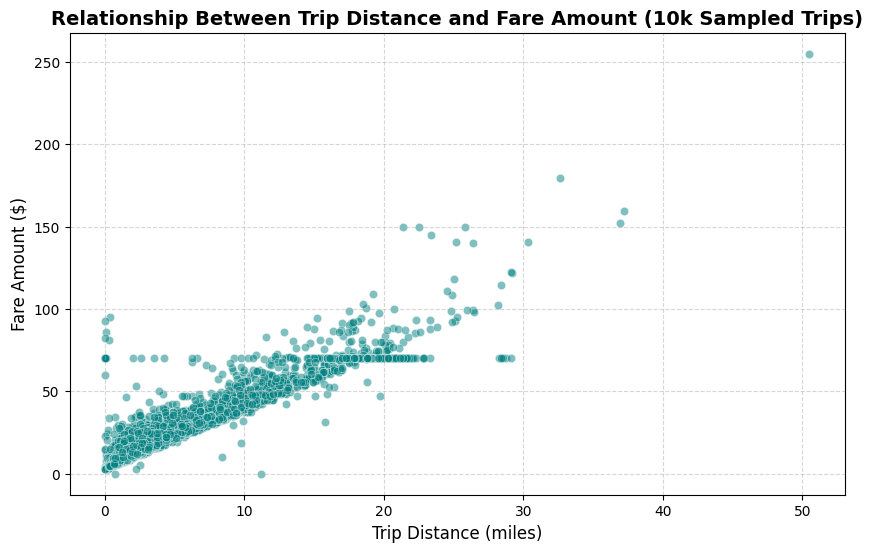

In [ ]:
# Filter out zero-distance trips for clean analysis
df_distance_fare = df[df['trip_distance'] > 0]

# Calculate Pearson correlation coefficient
correlation = df_distance_fare['trip_distance'].corr(df_distance_fare['fare_amount'])
print(f"Correlation between Trip Distance and Fare Amount: {correlation:.4f}")

# Visualise using a scatter plot (sampling a subset for plotting efficiency)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_distance_fare.sample(n=10000, random_state=42), x='trip_distance', y='fare_amount', alpha=0.5, color='teal')
plt.title('Relationship Between Trip Distance and Fare Amount (10k Sampled Trips)', fontsize=14, weight='bold')
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between Trip Duration and Fare Amount: 0.2739


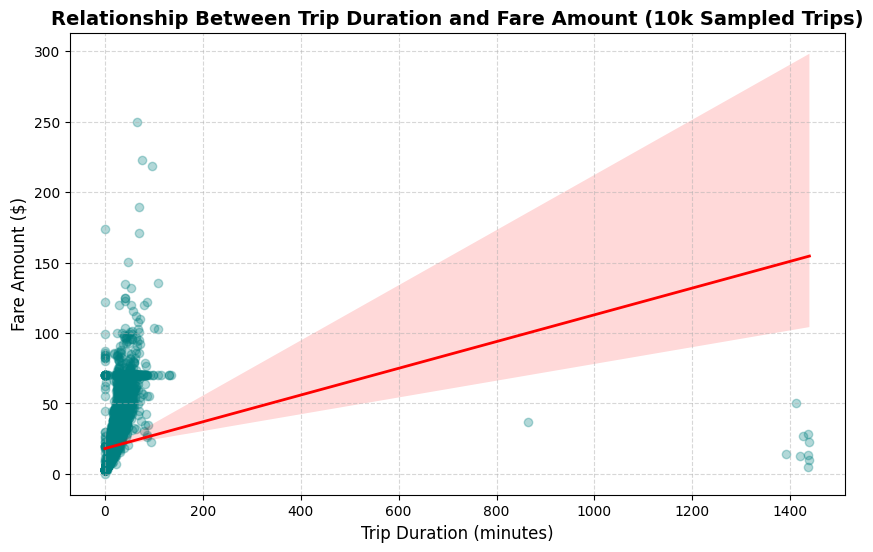

In [ ]:
# Show relationship between fare and trip duration
# Calculate Pearson correlation coefficient
duration_fare_corr = df['trip_duration_min'].corr(df['fare_amount'])
print(f"Correlation between Trip Duration and Fare Amount: {duration_fare_corr:.4f}")

# Visualise using a scatter plot with a regression trendline (on a sample of 10,000 for performance)
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(n=10000, random_state=42), x='trip_duration_min', y='fare_amount',
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Relationship Between Trip Duration and Fare Amount (10k Sampled Trips)', fontsize=14, weight='bold')
plt.xlabel('Trip Duration (minutes)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Correlation between Passenger Count and Fare Amount: 0.0448


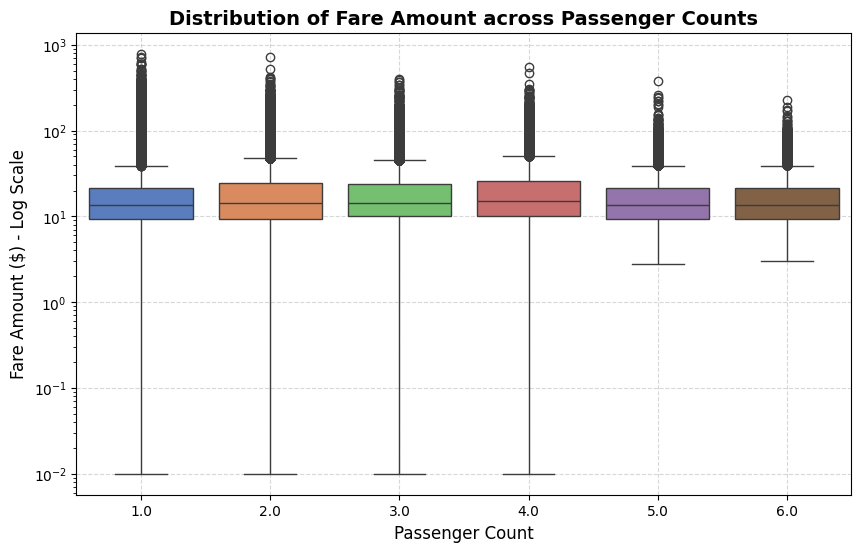

In [ ]:
# Show relationship between fare and number of passengers
# Calculate Pearson correlation coefficient
passenger_fare_corr = df['passenger_count'].corr(df['fare_amount'])
print(f"Correlation between Passenger Count and Fare Amount: {passenger_fare_corr:.4f}")

# Visualise using a boxplot to see the distribution of fares across different passenger groups
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='passenger_count', y='fare_amount', palette='muted')
plt.yscale('log')  # Log scale to handle outliers better and show distributions clearly
plt.title('Distribution of Fare Amount across Passenger Counts', fontsize=14, weight='bold')
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Fare Amount ($) - Log Scale', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Correlation between Trip Distance and Tip Amount: 0.5745


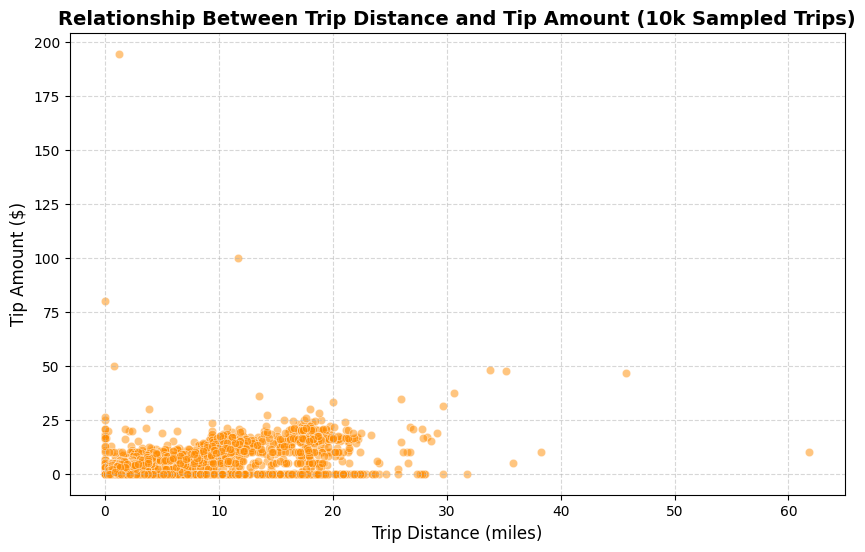

In [ ]:
# Show relationship between tip and trip distance
# Calculate Pearson correlation coefficient
distance_tip_corr = df['trip_distance'].corr(df['tip_amount'])
print(f"Correlation between Trip Distance and Tip Amount: {distance_tip_corr:.4f}")

# Visualise using a scatter plot (sampling a subset of 10,000 for plotting efficiency)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(n=10000, random_state=42), x='trip_distance', y='tip_amount', alpha=0.5, color='darkorange')
plt.title('Relationship Between Trip Distance and Tip Amount (10k Sampled Trips)', fontsize=14, weight='bold')
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Tip Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

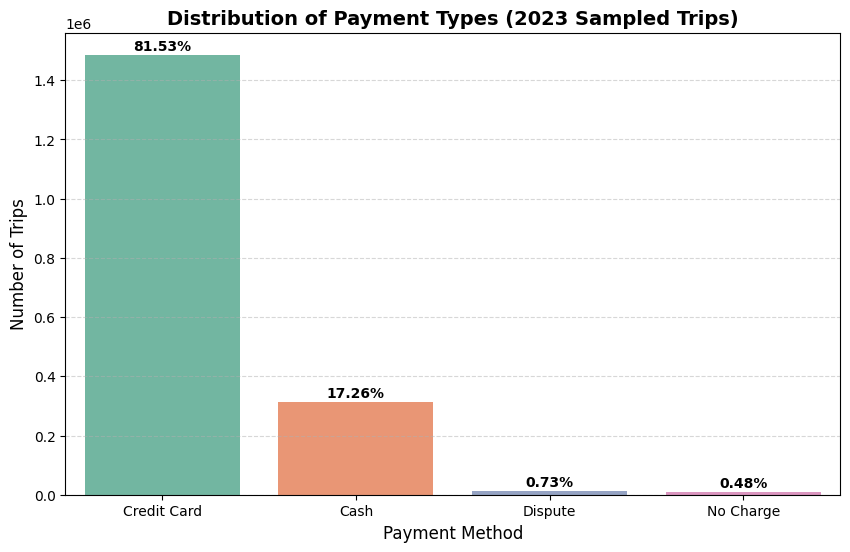

                 Count  Percentage (%)
payment_label                         
Credit Card    1486223       81.526623
Cash            314688       17.262181
Dispute          13390        0.734507
No Charge         8690        0.476689


In [ ]:
# Analyze the distribution of different payment types using the mapped labels
payment_counts = df['payment_label'].value_counts(dropna=False)
payment_percentages = df['payment_label'].value_counts(normalize=True, dropna=False) * 100

# Create a visualization of the payment methods
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Set2')
plt.title('Distribution of Payment Types (2023 Sampled Trips)', fontsize=14, weight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add percentage labels on top of the bars
for i, p in enumerate(payment_counts.values):
    percentage = payment_percentages.iloc[i]
    ax.text(i, p + (max(payment_counts.values) * 0.01), f"{percentage:.2f}%", ha='center', fontweight='bold')

plt.show()

# Display raw statistics
payment_summary = pd.DataFrame({
    'Count': payment_counts,
    'Percentage (%)': payment_percentages
})
print(payment_summary)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd
import os

# Let's inspect the directory tree to find the exact relative path of the shapefile
current_dir = os.getcwd()
print("Current working directory:", current_dir)

# Go up one level to look for the taxi_zones folder
parent_dir = os.path.dirname(current_dir)
print("Parent directory contents:", os.listdir(parent_dir))

# Check if taxi_zones exists in the parent directory
zones_dir = os.path.join(parent_dir, 'taxi_zones')
if os.path.exists(zones_dir):
    print("taxi_zones contents:", os.listdir(zones_dir))
    zones_path = os.path.join(zones_dir, 'taxi_zones.shp')
else:
    # Try absolute path or search locally
    zones_path = '/content/Assignments/EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp'

print("Attempting to load shapefile from:", zones_path)
zones = gpd.read_file(zones_path)
zones.head()

Current working directory: /content/Assignments/EDA/data_NYC_Taxi/trip_records
Parent directory contents: ['.ipynb_checkpoints', 'trip_records', 'taxi_zones']
taxi_zones contents: ['taxi_zones.shx', 'taxi_zones.sbn', 'taxi_zones.shp.xml', 'taxi_zones.shp', 'taxi_zones.sbx', 'taxi_zones.dbf', 'taxi_zones.prj']
Attempting to load shapefile from: /content/Assignments/EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

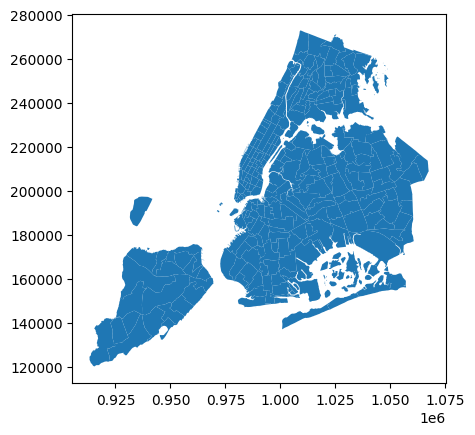

In [ ]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
# Since 'LocationID' is in zones and 'PULocationID' is in df, we perform a merge
# We will do a merge on the main df to match each trip record with its pickup zone name and borough
zones_subset = zones[['LocationID', 'zone', 'borough']]
df_merged = df.merge(zones_subset, left_on='PULocationID', right_on='LocationID', how='left')
print("Merged columns:", df_merged.columns.tolist())
print(f"Total rows after merging: {df_merged.shape[0]}")

Merged columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour', 'trip_duration_min', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_weekend', 'payment_label', 'fare_per_mile', 'speed_mph', 'quarter', 'LocationID', 'zone', 'borough']
Total rows after merging: 1823103


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
trip_counts = df_merged.groupby('PULocationID').size().reset_index(name='trip_count')
print("Top 10 busiest zones by pickup count:")
print(trip_counts.sort_values(by='trip_count', ascending=False).head(10))

Top 10 busiest zones by pickup count:
     PULocationID  trip_count
125           132       96477
229           237       86706
154           161       85684
228           236       77320
155           162       65450
131           138       64054
178           186       63228
222           230       61093
135           142       60683
163           170       54296


# Merge trip counts back to the zones GeoDataFrame to allow plotting
zones_with_trips = zones.merge(trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
# Fill NaN values with 0 (zones that had zero pickups in our sample)
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
print("Preview of zones with merged trip counts:")
display(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']].head())

In [ ]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trip_counts, left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN values with 0 (zones that had zero pickups in our sample)
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)

print("Preview of zones with merged trip counts:")
print(zones_with_trips[['LocationID', 'zone', 'borough', 'trip_count']].head())

Preview of zones with merged trip counts:
   LocationID                     zone        borough  trip_count
0           1           Newark Airport            EWR       199.0
1           2              Jamaica Bay         Queens         2.0
2           3  Allerton/Pelham Gardens          Bronx        34.0
3           4            Alphabet City      Manhattan      1843.0
4           5            Arden Heights  Staten Island        10.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

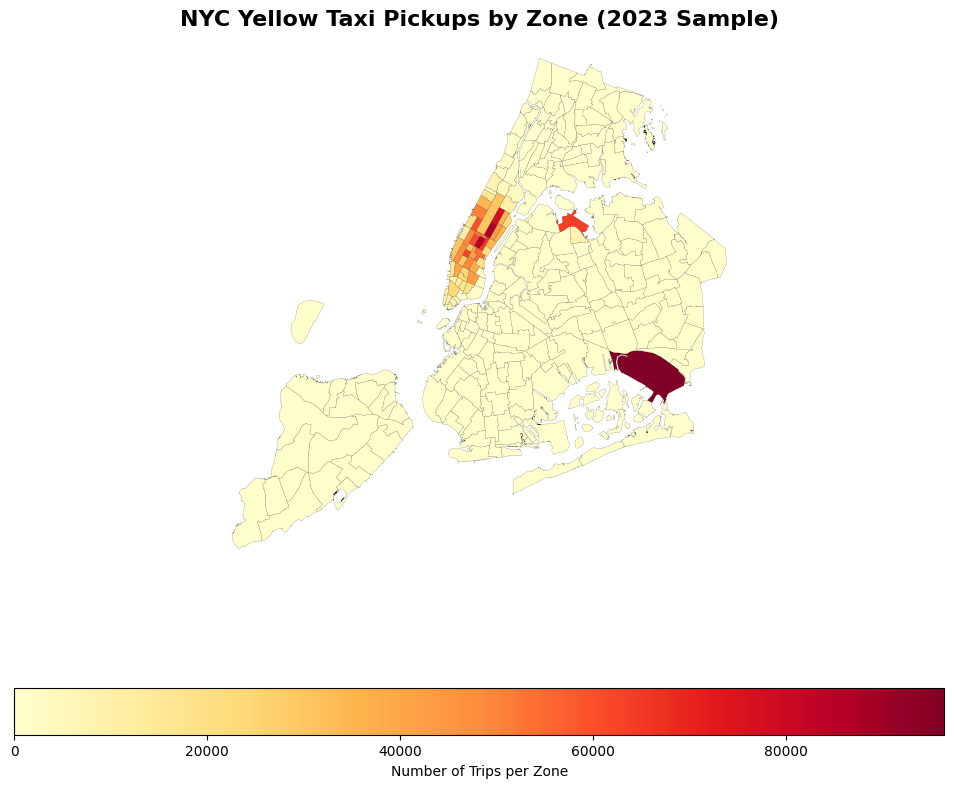

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it using the newly defined zones_with_trips
zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Number of Trips per Zone", 'orientation': "horizontal"},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.1
)

plt.title('NYC Yellow Taxi Pickups by Zone (2023 Sample)', fontsize=16, weight='bold')
ax.set_axis_off()  # Hide coordinates for clean map display
plt.show()

In [ ]:
# Display the zones sorted by the number of trips
zones_sorted = zones_with_trips.sort_values(by='trip_count', ascending=False)
display(zones_sorted[['LocationID', 'zone', 'borough', 'trip_count']].head(15))

,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,96477.0
236,237,Upper East Side South,Manhattan,86706.0
160,161,Midtown Center,Manhattan,85684.0
235,236,Upper East Side North,Manhattan,77320.0
161,162,Midtown East,Manhattan,65450.0
137,138,LaGuardia Airport,Queens,64054.0
185,186,Penn Station/Madison Sq West,Manhattan,63228.0
229,230,Times Sq/Theatre District,Manhattan,61093.0
141,142,Lincoln Square East,Manhattan,60683.0
169,170,Murray Hill,Manhattan,54296.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day



How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour



Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends



What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones



**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones



Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)



##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts




**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.